# ORF307 Homework 7

## Q2: Chocolate Manufacturing Company

In [10]:
# import basic python libraries

import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

(a) See the written portion above

(b) Solve the problem for various values of $t$ using cvxpy. You can set $t$ as a parameter as follows:

In [11]:
# Question 2b Coding Portion

x = cp.Variable(3, nonneg = True)
t = cp.Parameter()

A = np.array([[8, 6, 1],
             [4, 2, 1.5],
             [2, 1.5, .5]])
c = np.array([60, 30, 20])
b = np.array([48, 20, 8])
d = np.array([1, 1, 5])

# constraints = [A @ x <= b + d * t]
constraints = []
objective = cp.Minimize(-c.T @ x)

for i in range(3):
    constraints.append(A[i,:] @ x <= b[i] + d[i] * t)

problem = cp.Problem(objective, constraints)

# Solve for all values of t
t_values = np.linspace(-1, 1, 100)
x_vector = []
objective_vector = []
for t_val in t_values:
    t.value = t_val
    problem.solve()
    x_vector.append(x.value)
    objective_vector.append(problem.objective.value)

print("A set of optimal values for a set of t values:")
for i in range(len(t_values)):
    print(f"p({np.round(t_values[i],5)}) = {np.round(objective_vector[i],5)}")

A set of optimal values for a set of t values:
p(-1.0) = -120.0
p(-0.9798) = -124.0404
p(-0.9596) = -128.08081
p(-0.93939) = -132.12121
p(-0.91919) = -136.16162
p(-0.89899) = -140.20202
p(-0.87879) = -144.24242
p(-0.85859) = -148.28283
p(-0.83838) = -152.32323
p(-0.81818) = -156.36364
p(-0.79798) = -160.40404
p(-0.77778) = -164.44444
p(-0.75758) = -168.48485
p(-0.73737) = -172.52525
p(-0.71717) = -176.56566
p(-0.69697) = -180.60606
p(-0.67677) = -184.64646
p(-0.65657) = -188.68687
p(-0.63636) = -192.72727
p(-0.61616) = -196.76768
p(-0.59596) = -200.80808
p(-0.57576) = -204.84848
p(-0.55556) = -208.88889
p(-0.53535) = -212.92929
p(-0.51515) = -216.9697
p(-0.49495) = -221.0101
p(-0.47475) = -225.05051
p(-0.45455) = -229.09091
p(-0.43434) = -233.13131
p(-0.41414) = -237.17172
p(-0.39394) = -241.21212
p(-0.37374) = -245.25253
p(-0.35354) = -249.29293
p(-0.33333) = -253.33333
p(-0.31313) = -257.37374
p(-0.29293) = -261.41414
p(-0.27273) = -263.63636
p(-0.25253) = -264.84848
p(-0.23232) = -2

(c) Plot the optimal value $p^\star(td)$ and the lower bound defined around $p^\star(0)$

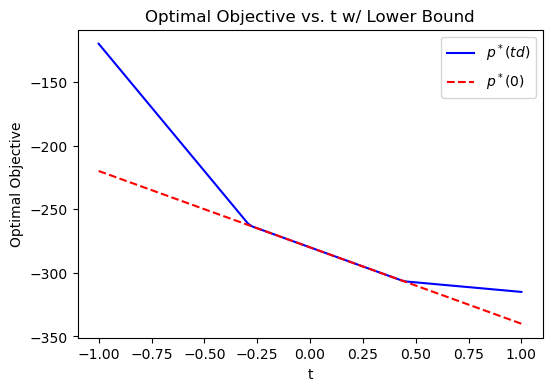

In [12]:
# Question 2c Coding Portion

plt.figure(figsize=(6,4))

plt.plot(t_values, objective_vector, 'b-', label='$p^*(td)$')

t.value = 0
problem.solve()
dual_vals = np.array([-con.dual_value for con in constraints])

slope = dual_vals @ d
lower_bound = problem.value + slope * t_values

plt.plot(t_values, lower_bound, color='r', linestyle='--', label='$p^*(0)$')

plt.xlabel('t')
plt.ylabel('Optimal Objective')
plt.title('Optimal Objective vs. t w/ Lower Bound')
plt.legend()
plt.show()


## Q3: Network Flow Problem

(a) See the written portion above

(b) Solve it using cvxpy.

In [13]:
A = np.array([
  [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, -1],
  [-1, 1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, -1, 0, 1, -1, 0, 0, 0, 0],
  [0, 0, 0, 0, 0, 0, 0, 1, 0, -1, 1, 0],
  [0, -1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0, 0, 0, 0, -1, 0, -1, 1],
  [0, 0, 0, 0, 0, -1, -1, 0, 1, 0, 0, 0],
  [0, 0, 1, -1, 0, 1, 0, 0, 0, 0, 0, 0]
  ])

b = np.array([2, 0, 2, -1, 0, -2, -6, 5])
c = np.array([1, 1, 1, 0, 3, 4, 2, 2, 1, 0, 3, 0])

x = cp.Variable(12, nonneg = True)

constraints = [A @ x == b]

objective = cp.Minimize(c.T @ x)

problem = cp.Problem(objective, constraints)
problem.solve()

print("Optimal Value:", problem.status)
print("Optimal Value:", np.round(problem.value, 5))
print("Optimal x Vector:", np.round(x.value, 5))

Optimal Value: optimal
Optimal Value: 28.0
Optimal x Vector: [0. 0. 0. 0. 0. 5. 2. 0. 1. 2. 1. 0.]
